# Cultural Analysis

Disclaimer: this notebook has been written with the aid of [ChatGPT](https://chatgpt.com/share/6a9415e2-362c-83eb-b0e4-24756072df4c).

## Preparation

### Loading Libraries

In [24]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

In [25]:
# Setting paths for the data folder and the .csv file
dataFolder = "C:/Users/sKALa/Repos/Semester 2/Dissertation/Albert Skalinski - Dissertation/data"
dataPath = dataFolder + "/cleanDataWithGroups.csv"

# Reading the cleaned data
df = pd.read_csv(dataPath)

# Checking if the data was read correctly
display(df.head())

,name,artist,genre,popularity,releaseDate,releaseYear,releaseMonth,timePeriod,energy,danceability,...,valence,speechiness,instrumentalness,acousticness,tempo,timeSignature,mode,key,durationMin,popularityGroup
0,Die With A Smile,"Lady Gaga, Bruno Mars",pop,100,2024-08-16,2024,8,2020s,0.592,0.521,...,0.535,0.0304,0.0000,0.3080,157.969,3,0,6,4.19,High popularity
1,BIRDS OF A FEATHER,Billie Eilish,pop,97,2024-05-17,2024,5,2020s,0.507,0.747,...,0.438,0.0358,0.0608,0.2000,104.978,4,1,2,3.51,High popularity
2,That’s So True,Gracie Abrams,pop,93,2024-10-18,2024,10,2020s,0.808,0.554,...,0.372,0.0368,0.0000,0.2140,108.548,4,1,1,2.77,High popularity
3,Taste,Sabrina Carpenter,pop,81,2024-08-23,2024,8,2020s,0.910,0.670,...,0.786,0.0634,0.0000,0.0939,112.966,4,0,0,2.62,High popularity
4,APT.,"ROSÉ, Bruno Mars",pop,98,2024-10-18,2024,10,2020s,0.783,0.777,...,0.939,0.2600,0.0000,0.0283,149.027,4,0,0,2.83,High popularity


## Genre Composition over Time

### Checking Genre and Time Period Values

In [26]:
# Checking available time periods
display(df["timePeriod"].value_counts())

# Checking available genres
display(df["genre"].value_counts())

timePeriod
2020s       2799
2010s        926
2000s        317
1990s        212
1980s         67
pre-1980      47
Name: count, dtype: int64

genre
electronic    555
pop           432
latin         395
hip-hop       352
ambient       321
lofi          298
rock          278
world         225
arabic        182
jazz          145
brazilian     137
classical     111
gaming        102
wellness       80
afrobeats      73
turkish        70
blues          69
punk           65
folk           62
indian         56
r&b            48
soul           44
gospel         34
korean         32
funk           28
cantopop       27
metal          26
j-pop          23
reggae         21
indie          16
k-pop          16
mandopop       14
soca           13
country        11
disco           7
Name: count, dtype: int64

### Defining the Time Period Order

In [27]:
# Defining time period order
timePeriodOrder = ["pre-1980", "1980s", "1990s", "2000s", "2010s", "2020s"]

### Selecting the Main Genres

In [28]:
# Selecting the 10 most represented genres
topGenres = df["genre"].value_counts().head(10).index

# Displaying selected genres
display(topGenres)

Index(['electronic', 'pop', 'latin', 'hip-hop', 'ambient', 'lofi', 'rock',
       'world', 'arabic', 'jazz'],
      dtype='object', name='genre')

Reduced the number of genres to 10. Originally it was 35. Otherwise, the graph would have been unreadable.

In [29]:
# Grouping less represented genres into one "Other" category
df["genreGroup"] = np.where(df["genre"].isin(topGenres), df["genre"], "Other")

# Checking the new genre groups
display(df["genreGroup"].value_counts())

genreGroup
Other         1185
electronic     555
pop            432
latin          395
hip-hop        352
ambient        321
lofi           298
rock           278
world          225
arabic         182
jazz           145
Name: count, dtype: int64

### Calculating Genre Composition by Time Period

In [30]:
# Calculating genre composition within each time period
genreComposition = pd.crosstab(df["timePeriod"], df["genreGroup"], normalize = "index") * 100

# Reordering the time periods
genreComposition = genreComposition.reindex(timePeriodOrder)

# Displaying the results
display(genreComposition.round(2))

genreGroup,Other,ambient,arabic,electronic,hip-hop,jazz,latin,lofi,pop,rock,world
timePeriod,,,,,,,,,,,
pre-1980,17.02,0.00,0.00,0.00,0.00,2.13,0.00,0.00,14.89,65.96,0.00
1980s,20.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,14.93,64.18,0.00
1990s,35.38,0.00,0.47,4.25,18.40,8.02,1.89,0.00,7.55,20.28,3.77
2000s,47.95,0.63,0.00,4.73,1.26,5.68,4.10,0.00,14.20,16.72,4.73
2010s,28.29,4.43,4.21,15.98,7.67,0.86,10.04,1.84,15.33,3.24,8.10
2020s,24.08,9.93,5.07,13.68,8.50,3.61,10.18,10.04,7.57,2.79,4.54


### Plotting Genre Composition Over Time

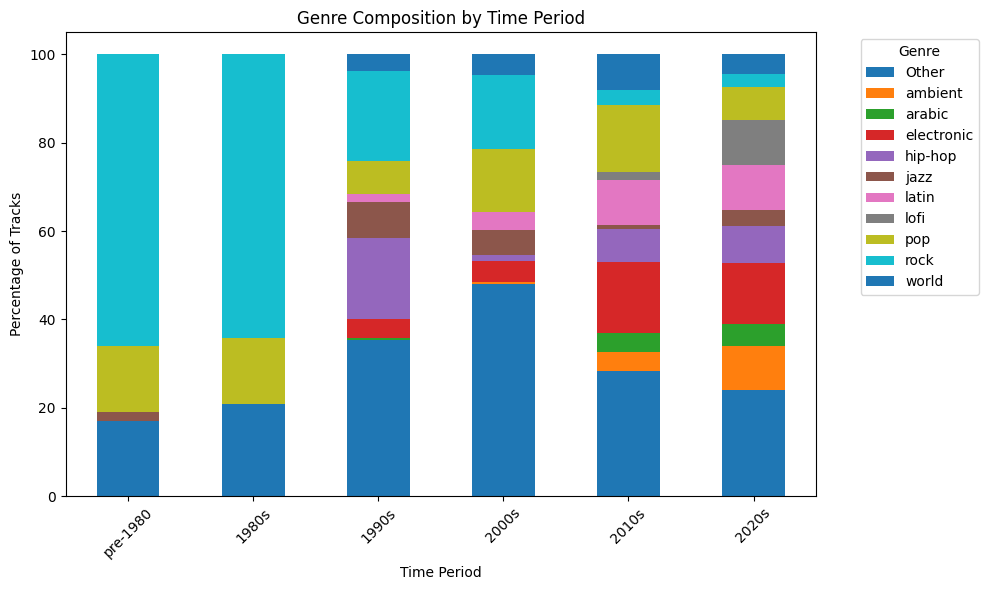

In [31]:
genreComposition.plot(kind = "bar", stacked = True, figsize = (10, 6))

plt.title("Genre Composition by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Percentage of Tracks")
plt.xticks(rotation = 45)
plt.legend(title = "Genre", bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.show()

Decided on a 100% stacked bar chart, because raw counts in the previous EDA showed, that the dataset is heavily concentrated on music from 2010s & 2020s, which is an important limitation.

### Five Most Represented Genres per Period

In [32]:
# Finding the five most represented genres in each time period
genreByPeriod = pd.crosstab(df["timePeriod"], df["genre"], normalize = "index") * 100

genreByPeriod = genreByPeriod.reindex(timePeriodOrder)

# Displaying the five most represented genres for each period
for period in timePeriodOrder:
    print(period)
    display(genreByPeriod.loc[period].sort_values(ascending = False).head(5).round(2))

pre-1980


genre
rock       65.96
pop        14.89
folk        6.38
country     4.26
blues       4.26
Name: pre-1980, dtype: float64

1980s


genre
rock      64.18
pop       14.93
blues     10.45
metal      5.97
reggae     2.99
Name: 1980s, dtype: float64

1990s


...

genre
rock         16.72
pop          14.20
punk         13.56
brazilian     8.52
blues         6.94
Name: 2000s, dtype: float64

2010s


genre
electronic    15.98
pop           15.33
latin         10.04
world          8.10
hip-hop        7.67
Name: 2010s, dtype: float64

2020s


genre
electronic    13.68
latin         10.18
lofi          10.04
ambient        9.93
hip-hop        8.50
Name: 2020s, dtype: float64

These tables have been produced for better readability.

Overall:
- rock dominates in older periods
- later periods become much more diverse

## Genre Popularity over Time

### Average Popularity by Genre

In [33]:
# Calculating average popularity by genre
averagePopularityByGenre = (df.groupby("genre")["popularity"].mean().sort_values(ascending = False))

# Displaying the results
display(averagePopularityByGenre.round(2))

genre
r&b           76.44
gaming        69.40
k-pop         68.50
metal         66.65
punk          66.25
rock          65.17
j-pop         64.96
hip-hop       62.02
pop           61.96
korean        61.69
indie         61.00
blues         59.67
reggae        58.14
folk          58.11
latin         54.75
mandopop      53.79
soul          52.70
electronic    51.80
turkish       51.04
afrobeats     50.25
wellness      49.51
ambient       48.95
arabic        48.69
country       48.45
lofi          47.02
jazz          46.34
gospel        46.03
classical     45.67
indian        45.05
soca          42.15
brazilian     39.93
funk          32.18
world         29.22
disco         25.86
cantopop      24.59
Name: popularity, dtype: float64

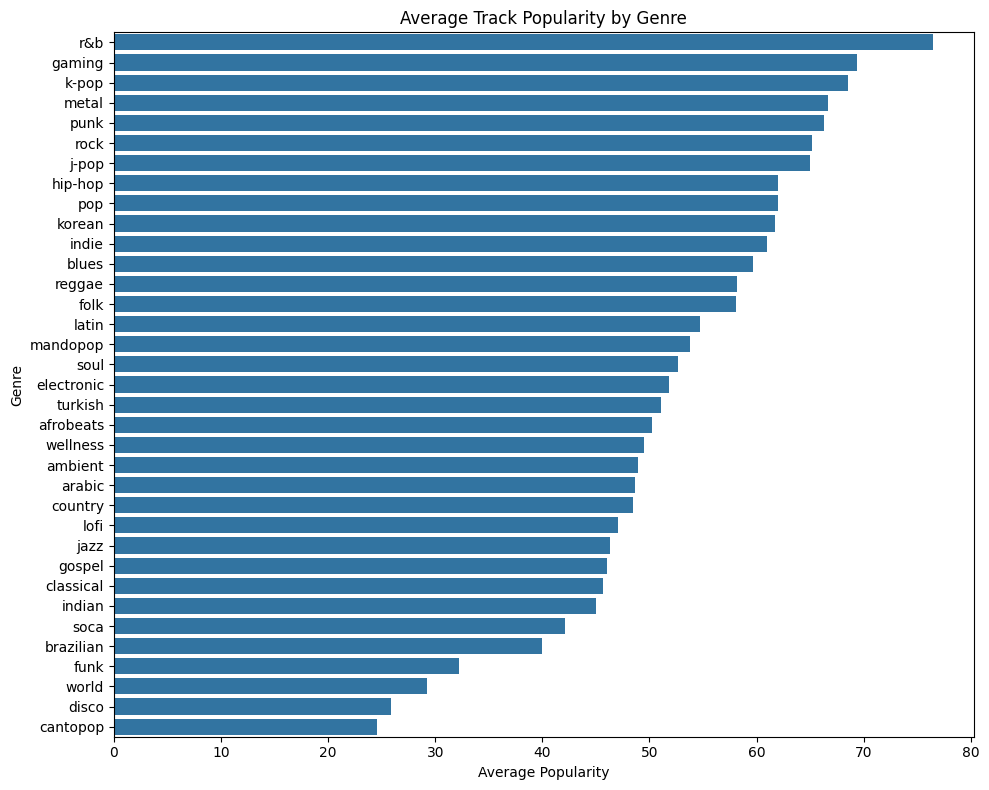

In [34]:
# Average popularity by genre
plt.figure(figsize = (10, 8))

sns.barplot(x = averagePopularityByGenre.values, y = averagePopularityByGenre.index)

plt.title("Average Track Popularity by Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Selecting Genres for the Temporal Comparison

In [35]:
# Counting tracks by genre and time period
genrePeriodCounts = pd.crosstab(df["genre"], df["timePeriod"])

# Keeping the main genres and ordering the time periods
genrePeriodCounts = genrePeriodCounts.reindex(index = topGenres, columns = timePeriodOrder)

display(genrePeriodCounts)

timePeriod,pre-1980,1980s,1990s,2000s,2010s,2020s
genre,,,,,,
electronic,0,0,9,15,148,383
pop,7,10,16,45,142,212
latin,0,0,4,13,93,285
hip-hop,0,0,39,4,71,238
ambient,0,0,0,2,41,278
lofi,0,0,0,0,17,281
rock,31,43,43,53,30,78
world,0,0,8,15,75,127
arabic,0,0,1,0,39,142


### Calculating Average Popularity by Genre and Time Period

In [36]:
# Calculating average popularity by genre and time period
genrePopularity = (df[df["genre"].isin(topGenres)].groupby(["genre", "timePeriod"])["popularity"].mean().unstack())

# Reordering rows and columns
genrePopularity = genrePopularity.reindex(index = topGenres, columns = timePeriodOrder)

display(genrePopularity.round(2))

timePeriod,pre-1980,1980s,1990s,2000s,2010s,2020s
genre,,,,,,
electronic,NaN,NaN,55.89,56.27,60.18,48.29
pop,76.00,77.80,75.00,77.42,64.82,54.57
latin,NaN,NaN,58.00,42.08,47.22,57.74
hip-hop,NaN,NaN,69.33,75.75,71.03,57.90
ambient,NaN,NaN,NaN,80.00,54.29,47.94
lofi,NaN,NaN,NaN,NaN,42.65,47.28
rock,74.74,74.16,69.67,67.96,62.97,52.87
world,NaN,NaN,36.62,28.60,29.68,28.56
arabic,NaN,NaN,35.00,NaN,49.90,48.45


### Removing Unreliable Genre-Period Combinations

In [37]:
# Removing genre-period averages based on fewer than 5 tracks
minimumTracks = 5

genrePopularityFiltered = genrePopularity.where(genrePeriodCounts >= minimumTracks)

display(genrePopularityFiltered.round(2))

timePeriod,pre-1980,1980s,1990s,2000s,2010s,2020s
genre,,,,,,
electronic,NaN,NaN,55.89,56.27,60.18,48.29
pop,76.00,77.80,75.00,77.42,64.82,54.57
latin,NaN,NaN,NaN,42.08,47.22,57.74
hip-hop,NaN,NaN,69.33,NaN,71.03,57.90
ambient,NaN,NaN,NaN,NaN,54.29,47.94
lofi,NaN,NaN,NaN,NaN,42.65,47.28
rock,74.74,74.16,69.67,67.96,62.97,52.87
world,NaN,NaN,36.62,28.60,29.68,28.56
arabic,NaN,NaN,NaN,NaN,49.90,48.45


If a genre has only one or two songs in a period, it's not meaningful.

### Genre Popularity Heatmap

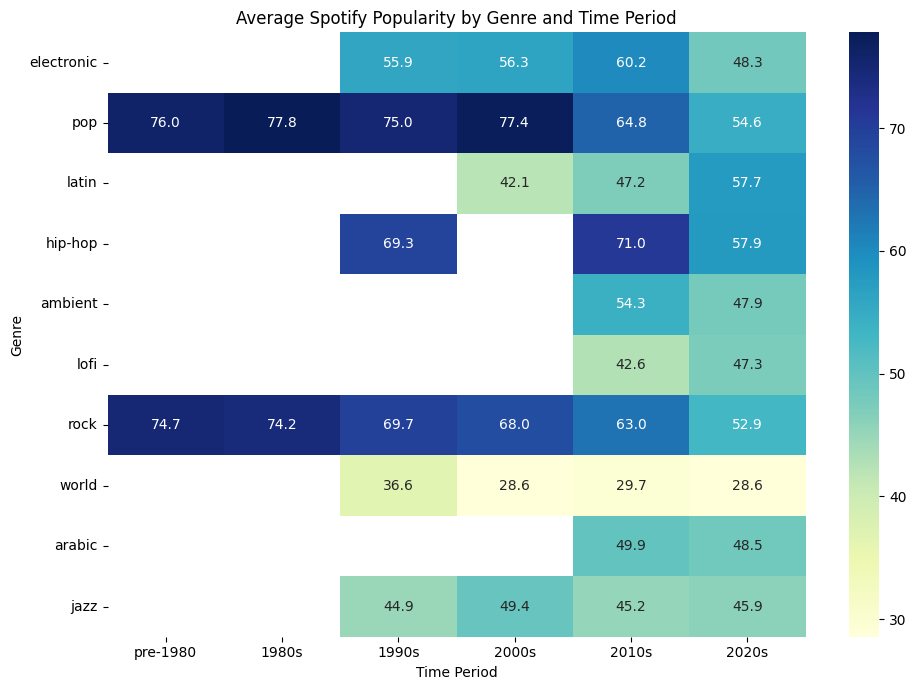

In [38]:
# Average popularity by genre and time period
plt.figure(figsize = (10, 7))

sns.heatmap(genrePopularityFiltered, annot = True, fmt = ".1f", cmap = "YlGnBu")

plt.title("Average Spotify Popularity by Genre and Time Period")
plt.xlabel("Time Period")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Add the Sample Size to the Analysis

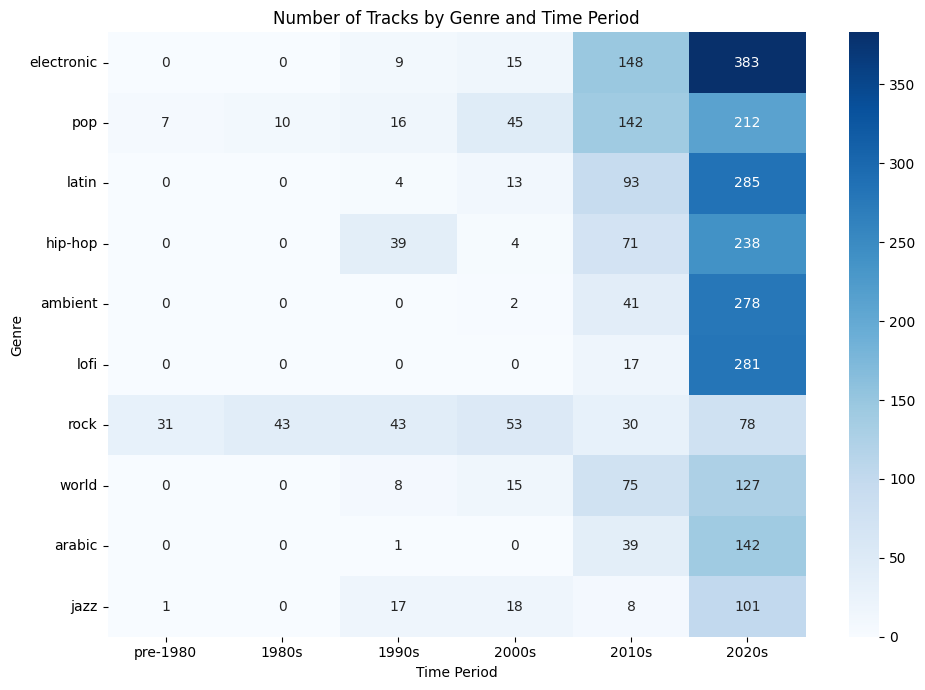

In [39]:
# Number of tracks by genre and time period
plt.figure(figsize = (10, 7))

sns.heatmap(genrePeriodCounts, annot = True, fmt = "d", cmap = "Blues")

plt.title("Number of Tracks by Genre and Time Period")
plt.xlabel("Time Period")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

The sample size behind the original heatmap.

Overall:
- pop and rock tracks from older periods have higher Spotify popularity than their recent counterparts
- older surviving tracks often have high Spotify popularity

## Audio Characteristics Over Time

### Selecting Audio Features

In [40]:
# Selecting audio features for temporal analysis
audioFeatures = ["energy", "danceability", "loudness", "liveness", "valence", "speechiness", "instrumentalness", "acousticness", "tempo",
                "durationMin"]

### Average Audio Features by Time Period

In [41]:
# Calculating average audio features by time period
audioFeaturesByPeriod = (df.groupby("timePeriod")[audioFeatures].mean().reindex(timePeriodOrder))

# Displaying the results
display(audioFeaturesByPeriod.round(3))

,energy,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,tempo,durationMin
timePeriod,,,,,,,,,,
pre-1980,0.601,0.564,-10.317,0.159,0.649,0.064,0.045,0.262,121.665,4.131
1980s,0.705,0.601,-8.368,0.162,0.614,0.054,0.026,0.155,120.621,4.441
1990s,0.606,0.584,-9.557,0.170,0.546,0.093,0.128,0.288,113.842,4.573
2000s,0.631,0.590,-7.870,0.183,0.555,0.076,0.119,0.289,118.231,4.055
2010s,0.597,0.618,-8.137,0.160,0.480,0.095,0.139,0.344,119.380,3.706
2020s,0.560,0.631,-10.146,0.169,0.453,0.109,0.264,0.377,117.981,3.112


### Standardising the Audio Features

In [42]:
# Standardising audio features so they can be compared on the same scale
standardisedAudio = (df[audioFeatures] - df[audioFeatures].mean()) / df[audioFeatures].std()

# Adding time period back to the standardised data
standardisedAudio["timePeriod"] = df["timePeriod"]

# Calculating average standardised values by time period
standardisedAudioByPeriod = (standardisedAudio.groupby("timePeriod")[audioFeatures].mean().reindex(timePeriodOrder))

display(standardisedAudioByPeriod.round(2))

,energy,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,tempo,durationMin
timePeriod,,,,,,,,,,
pre-1980,0.09,-0.31,-0.11,-0.07,0.67,-0.37,-0.47,-0.28,0.12,0.52
1980s,0.51,-0.11,0.15,-0.04,0.54,-0.47,-0.52,-0.61,0.09,0.75
1990s,0.11,-0.20,-0.01,0.02,0.27,-0.08,-0.24,-0.20,-0.15,0.84
2000s,0.21,-0.17,0.22,0.13,0.31,-0.26,-0.27,-0.20,0.00,0.47
2010s,0.08,-0.02,0.19,-0.06,0.02,-0.06,-0.21,-0.03,0.04,0.22
2020s,-0.07,0.05,-0.09,0.01,-0.09,0.07,0.14,0.07,-0.01,-0.21


These were standardised, because some of the features operate on a different scale.<br>
- 0 - approx. the overall dataset average
- positive - above the average
- negative - below the average

### Audio Features by Time Period Heatmap

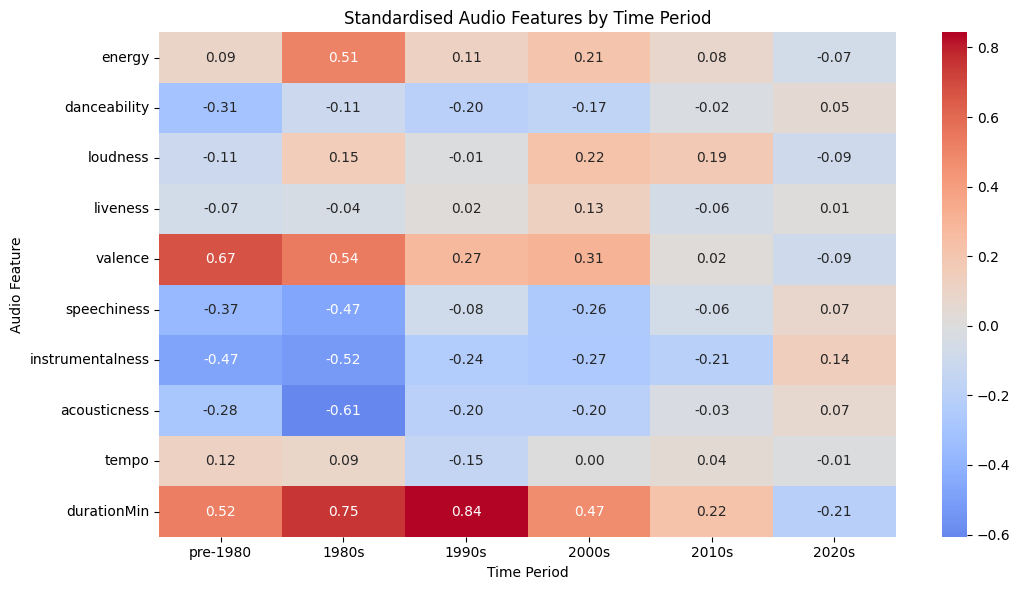

In [43]:
# Standardised audio features by time period
plt.figure(figsize = (11, 6))

sns.heatmap(standardisedAudioByPeriod.T, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)

plt.title("Standardised Audio Features by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

### Trend Table

In [44]:
# Comparing the oldest and newest time periods
periodChange = (standardisedAudioByPeriod.loc["2020s"] - standardisedAudioByPeriod.loc["pre-1980"])

# Ordering features by the size of the change
periodChange = periodChange.sort_values()

display(periodChange.round(2))

valence            -0.76
durationMin        -0.74
energy             -0.17
tempo              -0.13
loudness            0.02
liveness            0.07
acousticness        0.35
danceability        0.35
speechiness         0.44
instrumentalness    0.61
dtype: float64

This shows which characteristics changed the most between the start date and the end date of the dataset.

Overall:
- valence shows a strong decline - older tracks are more positive-sounding
- track duration falls strongly - 1990s having the longests tracks
- instrumentalness rises substantially
- energy changes very little, but 1980s were especially energetic